<a href="https://colab.research.google.com/github/JaySky-mvv/week11_lab/blob/main/Polynomial_Regression_and_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a id="toc"></a>

# Polynomial Regression and Regularization


---

## Table of Contents

- [Introduction](#introduction)
- [Part 1: Detailed Tutorial](#part-1-detailed-tutorial)
  - [1.1 Linear vs Polynomial Regression](#11-linear-vs-polynomial-regression)
  - [1.2 Polynomial Features & Overfitting](#12-polynomial-features--overfitting)
  - [1.3 Regularization: Ridge, Lasso, Elastic Net](#13-regularization-ridge-lasso-elastic-net)
  - [1.4 Hyperparameter Tuning with Cross-Validation](#14-hyperparameter-tuning-with-cross-validation)
- [Part 2: Coding Tasks (100 marks)](#part-2-coding-tasks-100-marks)
- [Bonus Section (10% extra marks)](#bonus-section-10-extra-marks)
- [Conclusion](#conclusion)
- [Submission](#submission)

[↑ Back to top](#toc)

---

<a id="introduction"></a>

## Introduction

### Learning objectives

By the end of this lab, you should be able to:

- Explain when linear models fail for nonlinear data and how polynomial feature expansion helps.
- Fit polynomial regression models in `scikit-learn` and diagnose **overfitting** using train vs test error.
- Describe **Ridge (L2)**, **Lasso (L1)**, and **Elastic Net** penalties in words and equations, and interpret coefficient shrinkage and sparsity.
- Tune hyperparameters such as **polynomial degree** and **regularization strength** using **cross-validation** (`RidgeCV`, `LassoCV`, `GridSearchCV` on `Pipeline`).
- Communicate results with clear plots (titles, axis labels, legends, grids) and concise comparisons.


### Overview

You will work with a **single synthetic dataset** throughout the lab: a noisy sine curve. A simple linear model cannot capture the oscillation, so we expand inputs with `PolynomialFeatures`. High-degree polynomials can **overfit**; **regularization** trades off flexibility for stability. Finally, you will use **cross-validation** to pick hyperparameters responsibly and quantify generalization.

**Important:** The notebook performs one **70% train / 30% test** split at the start. **Reuse the same split** for every experiment unless a task explicitly asks otherwise.

[↑ Back to top](#toc)

In [30]:
%matplotlib inline

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LinearRegression,
    Ridge,
    RidgeCV,
    LassoCV,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import GridSearchCV, train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Consistent plotting style
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Reproducible synthetic dataset (used everywhere in this lab)
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.1, size=X.shape[0])

# Single train/test split for the whole notebook (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# Sort test set for prettier plotting curves (optional; does not change metrics)
sort_idx = np.argsort(X_test.ravel())
X_test_sorted = X_test[sort_idx]
y_test_sorted = y_test[sort_idx]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

X shape: (100, 1), y shape: (100,)
Train: 60 samples | Test: 40 samples


<a id="part-1-detailed-tutorial"></a>

# Part 1: Detailed Tutorial

This section is a guided walkthrough. Read the Markdown carefully, run each code cell in order, and connect the plots to the concepts (bias, variance, overfitting, regularization).

[↑ Back to top](#toc)

<a id="11-linear-vs-polynomial-regression"></a>

## 1.1 Linear vs Polynomial Regression

A **linear regression** model assumes the target is approximately an **affine function** of the input features:

$$
y \approx w_0 + \sum_{j=1}^{p} w_j x_j.
$$

When the true relationship is **nonlinear** (here, \(y \approx \sin(x)\)), a straight line is **structurally misspecified**: it has **high bias** for this problem, no matter how much data you collect.

**Polynomial regression** keeps a **linear model in the parameters** but augments the inputs with nonlinear transformations, e.g. \([x, x^2, x^3, ..]\). This can reduce bias, but overly rich expansions can **overfit** (high variance), which we address later with **regularization** and **model selection**.

Below, we fit ordinary least squares linear regression on the original 1D feature \(x\) and visualize **predictions** and **residuals**.

[↑ Back to top](#toc)

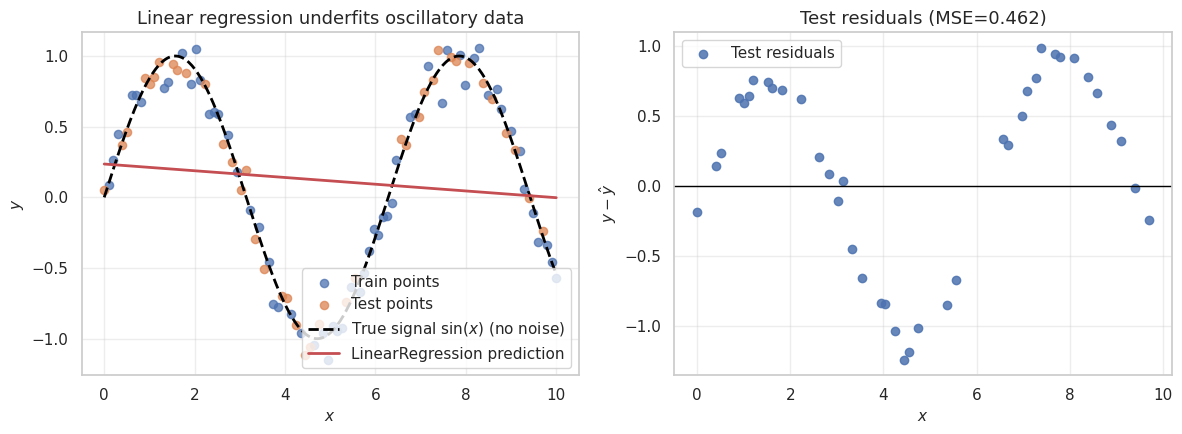

Train MSE: 0.4435 | Train R2: 0.0107
Test  MSE: 0.4622 | Test  R2: -0.0503


In [31]:
# 1.1 Linear regression on raw x (degree-1 feature space)
lin = LinearRegression()
lin.fit(X_train, y_train)

y_train_pred = lin.predict(X_train)
y_test_pred = lin.predict(X_test)

train_mse_lin = mean_squared_error(y_train, y_train_pred)
test_mse_lin = mean_squared_error(y_test, y_test_pred)

xx = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
yy_true = np.sin(xx).ravel()  # noise-free signal for reference
yy_hat = lin.predict(xx)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot A: data + linear fit vs underlying sine
axes[0].scatter(X_train, y_train, alpha=0.75, label="Train points", s=35)
axes[0].scatter(X_test, y_test, alpha=0.75, label="Test points", s=35)
axes[0].plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True signal $\\sin(x)$ (no noise)")
axes[0].plot(xx, yy_hat, color="C3", linewidth=2, label="LinearRegression prediction")
axes[0].set_title("Linear regression underfits oscillatory data")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.35)

# Plot B: residuals on the test set (sorted for readability)
residuals = y_test_sorted - lin.predict(X_test_sorted)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].scatter(X_test_sorted.ravel(), residuals, alpha=0.85, label="Test residuals")
axes[1].set_title(f"Test residuals (MSE={test_mse_lin:.3f})")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y - \\hat{y}$")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Train MSE: {train_mse:.4f} | Train R2: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f} | Test  R2: {test_r2:.4f}")

<a id="12-polynomial-features--overfitting"></a>

## 1.2 Polynomial Features & Overfitting Demonstration

We construct polynomial features with `PolynomialFeatures(degree=d)` and fit `LinearRegression` on the expanded design matrix. This is still **linear regression**, but in a higher-dimensional basis of monomials in \(x\).

### Bias–variance intuition (short)

- **Bias** measures systematic error from using a too-simple model family (underfitting).
- **Variance** measures sensitivity to training sample noise (overfitting).
- **Total error** often decomposes (conceptually) as **bias** + **variance** + irreducible noise; increasing \(d\) typically **reduces bias** but can **increase variance**.

We will compare degrees **1, 3, 8, 15** and plot **train vs test MSE** vs degree.

[↑ Back to top](#toc)

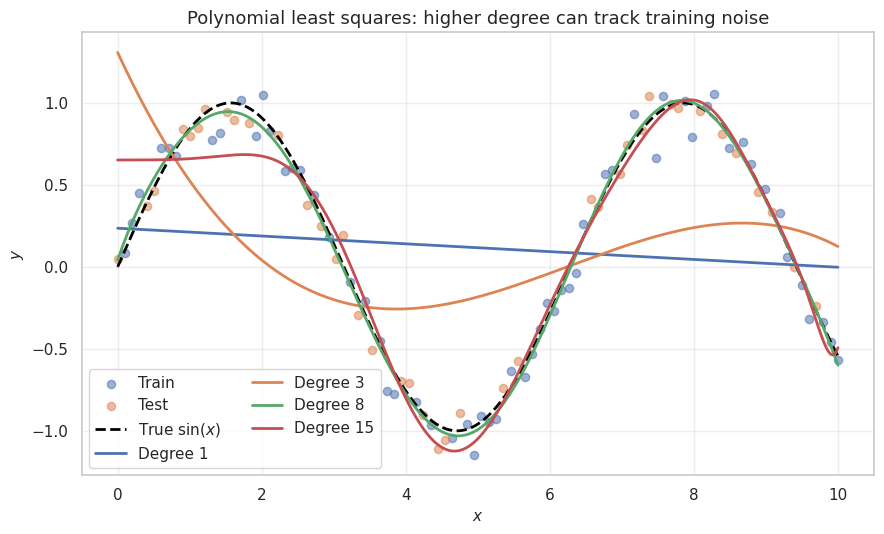

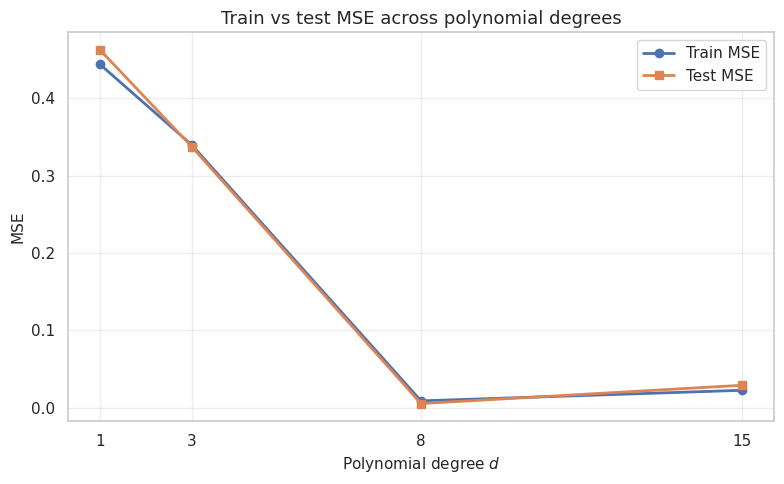

,degree,train_mse,test_mse
0,1,0.443510,0.462151
1,3,0.339551,0.337265
2,8,0.009084,0.005588
3,15,0.022735,0.029227


In [32]:
degrees_demo = [1, 3, 8, 15]
models_by_degree = {}
train_mse_by_degree = []
test_mse_by_degree = []

for d in degrees_demo:
    poly = PolynomialFeatures(degree=d, include_bias=True)
    Xtr = poly.fit_transform(X_train)
    Xte = poly.transform(X_test)

    model = LinearRegression()
    model.fit(Xtr, y_train)
    models_by_degree[d] = (poly, model)

    train_mse_by_degree.append(mean_squared_error(y_train, model.predict(Xtr)))
    test_mse_by_degree.append(mean_squared_error(y_test, model.predict(Xte)))

# Figure 1: overlay polynomial fits
plt.figure(figsize=(9, 5.5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\\sin(x)$")

colors = sns.color_palette("deep", n_colors=len(degrees_demo))
for d, c in zip(degrees_demo, colors):
    poly, model = models_by_degree[d]
    Xx = poly.transform(xx)
    plt.plot(xx.ravel(), model.predict(Xx), linewidth=2, color=c, label=f"Degree {d}")

plt.title("Polynomial least squares: higher degree can track training noise")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best", ncol=2)
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# Figure 2: train vs test MSE vs degree (learning-style diagnostic for this basis)
plt.figure(figsize=(8, 5))
plt.plot(degrees_demo, train_mse_by_degree, marker="o", linewidth=2, label="Train MSE")
plt.plot(degrees_demo, test_mse_by_degree, marker="s", linewidth=2, label="Test MSE")
plt.title("Train vs test MSE across polynomial degrees")
plt.xlabel("Polynomial degree $d$")
plt.ylabel("MSE")
plt.xticks(degrees_demo)
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

mse_table = pd.DataFrame(
    {"degree": degrees_demo, "train_mse": train_mse_by_degree, "test_mse": test_mse_by_degree}
)
mse_table

**Reading the plot:** when **train MSE** keeps dropping but **test MSE** worsens, the model is likely **overfitting**: it explains idiosyncratic noise in the training set rather than the stable structure of sin(x).

[↑ Back to top](#toc)

<a id="13-regularization-ridge-lasso-elastic-net"></a>

## 1.3 Regularization — Ridge (L2), Lasso (L1), and Elastic Net


### Ridge regression (L2 penalty)

Ridge minimizes **MSE plus an L2 penalty** on weights (excluding intercept handling in notation).

In `scikit-learn`, **`alpha`** plays the role of **regularization strength** (analogous to \\(\\lambda\\) in many textbooks). Larger \\(\\alpha\\) increases **shrinkage** toward smaller **L2 norm**.

### Lasso regression (L1 penalty)

Lasso uses an **L1 penalty**, which can drive some coefficients **exactly to zero**, yielding **sparse** models.
### Elastic Net (L1 + L2)

Elastic Net blends L1 and L2 with **mixing parameter** `l1_ratio` \\(\\in [0,1]\\).
where \\(\\rho\\) is `l1_ratio` in `scikit-learn`.

### When to use which (practical guidance)

- **Ridge:** many small/moderate coefficients; strong **variance reduction**; rarely zeros coefficients.
- **Lasso:** encourages **sparsity** (automatic feature selection in linear models).
- **Elastic Net:** useful when features are **correlated** (common with polynomials); often more stable than pure Lasso.

Below we fix a **high-degree polynomial basis** (degree **15**) to make overfitting likely, then compare **Ridge**, **Lasso**, and **ElasticNet** with **`alpha=1.0`** (and `l1_ratio=0.5` for Elastic Net).

[↑ Back to top](#toc)

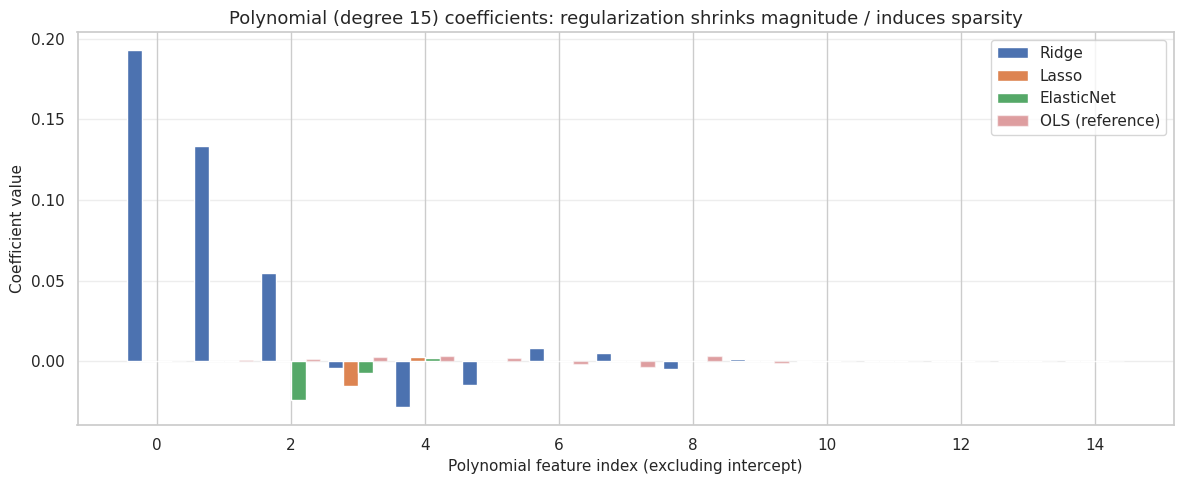

,model,test_mse,num_zero_coef (non-intercept)
1,Ridge,0.010863,0
0,OLS (poly d=15),0.029227,0
3,ElasticNet,0.053193,2
2,Lasso,0.060719,3


In [33]:
d_reg = 15
poly_reg = PolynomialFeatures(degree=d_reg, include_bias=True)
Xtr_p = poly_reg.fit_transform(X_train)
Xte_p = poly_reg.transform(X_test)

# Unregularized high-degree model (reference)
ols = LinearRegression()
ols.fit(Xtr_p, y_train)
test_mse_ols = mean_squared_error(y_test, ols.predict(Xte_p))

# Regularized models (alpha = 1.0 as requested)
ridge = Ridge(alpha=1.0, solver="svd")
lasso = Lasso(alpha=1.0, random_state=42, max_iter=200_000)
enet = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=200_000)

ridge.fit(Xtr_p, y_train)
lasso.fit(Xtr_p, y_train)
enet.fit(Xtr_p, y_train)

preds = {
    "OLS (poly d=15)": ols.predict(Xte_p),
    "Ridge": ridge.predict(Xte_p),
    "Lasso": lasso.predict(Xte_p),
    "ElasticNet": enet.predict(Xte_p),
}

mse_rows = []
for name, yhat in preds.items():
    mse_rows.append({"model": name, "test_mse": float(mean_squared_error(y_test, yhat))})

mse_df = pd.DataFrame(mse_rows).sort_values("test_mse")

# Coefficient magnitudes (exclude intercept for interpretability of shrinkage/sparsity)
feature_names = poly_reg.get_feature_names_out(["x"])
coef_frame = pd.DataFrame(
    {
        "feature": feature_names,
        "ols": ols.coef_,
        "ridge": ridge.coef_,
        "lasso": lasso.coef_,
        "elasticnet": enet.coef_,
    }
).set_index("feature")

non_intercept = coef_frame.index != "1"
cf = coef_frame.loc[non_intercept]

plt.figure(figsize=(12, 5))
xpos = np.arange(len(cf))
width = 0.22
plt.bar(xpos - 1.5 * width, cf["ridge"], width=width, label="Ridge")
plt.bar(xpos - 0.5 * width, cf["lasso"], width=width, label="Lasso")
plt.bar(xpos + 0.5 * width, cf["elasticnet"], width=width, label="ElasticNet")
plt.bar(xpos + 1.5 * width, cf["ols"], width=width, label="OLS (reference)", alpha=0.55)
plt.title("Polynomial (degree 15) coefficients: regularization shrinks magnitude / induces sparsity")
plt.ylabel("Coefficient value")
plt.xlabel("Polynomial feature index (excluding intercept)")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
plt.show()

zero_counts = {
    "ridge": int(np.sum(ridge.coef_[1:] == 0)),
    "lasso": int(np.sum(lasso.coef_[1:] == 0)),
    "elasticnet": int(np.sum(enet.coef_[1:] == 0)),
}

summary_reg = mse_df.copy()
summary_reg["num_zero_coef (non-intercept)"] = summary_reg["model"].map(
    {
        "Ridge": zero_counts["ridge"],
        "Lasso": zero_counts["lasso"],
        "ElasticNet": zero_counts["elasticnet"],
        "OLS (poly d=15)": int(np.sum(ols.coef_[1:] == 0)),
    }
)
summary_reg

**Interpretation:** Lasso’s **L1** penalty often produces **exact zeros** (sparse solutions), while Ridge tends to **shrink** many coefficients smoothly. Elastic Net is a compromise when features are correlated.

[↑ Back to top](#toc)

<a id="14-hyperparameter-tuning-with-cross-validation"></a>

## 1.4 Hyperparameter Tuning with Cross-Validation

Two key hyperparameters in this lab:

- **Polynomial degree** \(d\): controls model complexity / basis size.
- **Regularization strength** \\(\\alpha\\) (`alpha` in `sklearn`): controls shrinkage.

We should not tune these by peeking at the **test** set. Instead:

- `RidgeCV` / `LassoCV` efficiently tune **`alpha`** using built-in cross-validation for a fixed feature pipeline.
- `GridSearchCV` can tune **multiple** steps jointly, e.g. `poly__degree` and `ridge__alpha` inside a `Pipeline`.

Below:

1. Fit `RidgeCV` and `LassoCV` on a **degree-15 polynomial pipeline** (for illustration).
2. Fit a **joint** `GridSearchCV` on `Pipeline([("poly", PolynomialFeatures()), ("ridge", Ridge())])`.
3. Report **best parameters**, **best CV score**, and **final test MSE**.
4. Plot **coefficient paths** as a function of `alpha` for Ridge and Lasso (on a shared polynomial degree for a fair visualization).

[↑ Back to top](#toc)

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=9.1333e-32): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.86555e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.54997e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=7.04817e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.94539e-30): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python

RidgeCV best alpha: 0.01
LassoCV best alpha: 0.01


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.71561e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)



GridSearchCV (Pipeline) best params: {'poly__degree': 10, 'ridge__alpha': np.float64(0.001)}
Best CV score (neg MSE): -0.013272709716808703
Final TEST MSE with best pipeline: 0.007030


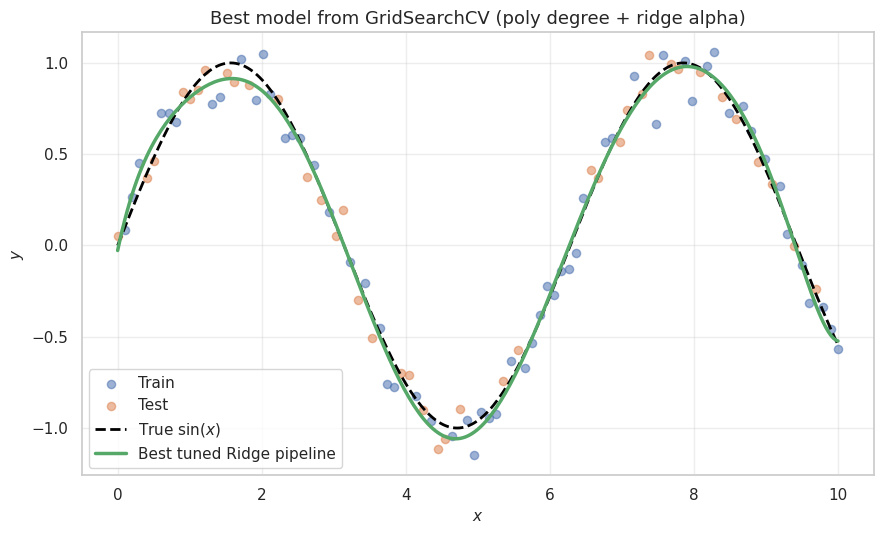

In [34]:
alphas = np.logspace(-2, 3, 20)

# --- Built-in CV for alpha (fixed high-degree basis for illustration) ---
# solver="svd" improves numerical stability for ill-conditioned polynomial designs
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(Xtr_p, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=500_000)
lasso_cv.fit(Xtr_p, y_train)

print("RidgeCV best alpha:", float(ridge_cv.alpha_))
print("LassoCV best alpha:", float(lasso_cv.alpha_))

# --- Joint tuning: polynomial degree + ridge alpha ---
pipe = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(include_bias=True)),
        ("ridge", Ridge(solver="auto")),
    ]
)

param_grid = {
    "poly__degree": [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15],
    "ridge__alpha": np.logspace(-3, 3, 10),
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

best = grid.best_estimator_
y_test_hat_best = best.predict(X_test)
test_mse_best = mean_squared_error(y_test, y_test_hat_best)

print("\nGridSearchCV (Pipeline) best params:", grid.best_params_)
print("Best CV score (neg MSE):", float(grid.best_score_))
print(f"Final TEST MSE with best pipeline: {test_mse_best:.6f}")

# Plot best tuned predictions
plt.figure(figsize=(9, 5.5))
plt.scatter(X_train, y_train, alpha=0.55, s=35, label="Train")
plt.scatter(X_test, y_test, alpha=0.55, s=35, label="Test")
plt.plot(xx, yy_true, color="black", linestyle="--", linewidth=2, label="True $\\sin(x)$")
plt.plot(xx.ravel(), best.predict(xx), color="C2", linewidth=2.5, label="Best tuned Ridge pipeline")
plt.title("Best model from GridSearchCV (poly degree + ridge alpha)")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(loc="best")
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

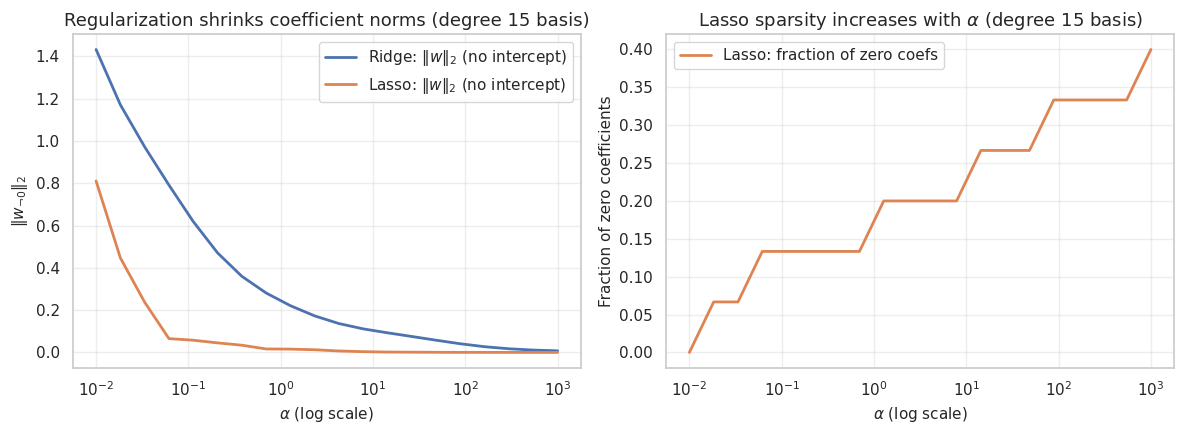

In [35]:
# Coefficient paths vs alpha (Ridge vs Lasso) on the SAME basis: degree 15
coef_paths = {"ridge": [], "lasso": []}

for a in alphas:
    rr = Ridge(alpha=float(a), solver="svd").fit(Xtr_p, y_train)
    ll = Lasso(alpha=float(a), random_state=42, max_iter=200_000).fit(Xtr_p, y_train)

    # Track L2 norm of non-intercept coefficients (variance-related complexity)
    coef_paths["ridge"].append(np.linalg.norm(rr.coef_[1:], ord=2))
    coef_paths["lasso"].append(np.linalg.norm(ll.coef_[1:], ord=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(alphas, coef_paths["ridge"], linewidth=2, label="Ridge: $\\|w\\|_2$ (no intercept)")
axes[0].plot(alphas, coef_paths["lasso"], linewidth=2, label="Lasso: $\\|w\\|_2$ (no intercept)")
axes[0].set_xscale("log")
axes[0].set_title("Regularization shrinks coefficient norms (degree 15 basis)")
axes[0].set_xlabel("$\\alpha$ (log scale)")
axes[0].set_ylabel("$\\|w_{\\neg 0}\\|_2$")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.35)

# Sparsity path for Lasso: fraction of non-intercept coefficients exactly zero
sparsity = []
for a in alphas:
    ll = Lasso(alpha=float(a), random_state=42, max_iter=200_000).fit(Xtr_p, y_train)
    sparsity.append(np.mean(ll.coef_[1:] == 0.0))

axes[1].plot(alphas, sparsity, linewidth=2, color="C1", label="Lasso: fraction of zero coefs")
axes[1].set_xscale("log")
axes[1].set_title("Lasso sparsity increases with $\\alpha$ (degree 15 basis)")
axes[1].set_xlabel("$\\alpha$ (log scale)")
axes[1].set_ylabel("Fraction of zero coefficients")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

### Tutorial summary table (sanity check)

The numeric values below depend on the fixed synthetic split, but the **ordering** should illustrate the main story: **linear underfits**, **high-degree OLS overfits**, **regularization stabilizes**, and **CV-tuned** models aim for the best test performance without manual guessing.

[↑ Back to top](#toc)

In [36]:
# Build a compact comparison table for the tutorial models discussed above
rows = []

rows.append(
    {
        "model": "LinearRegression (raw x)",
        "notes": "degree 1 basis",
        "test_mse": float(test_mse_lin),
    }
)

rows.append(
    {
        "model": "Polynomial OLS (d=15)",
        "notes": "unregularized",
        "test_mse": float(test_mse_ols),
    }
)

rows.append(
    {
        "model": "Ridge (d=15, alpha=1)",
        "notes": "hand-chosen alpha",
        "test_mse": float(mean_squared_error(y_test, ridge.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "Lasso (d=15, alpha=1)",
        "notes": "hand-chosen alpha",
        "test_mse": float(mean_squared_error(y_test, lasso.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "ElasticNet (d=15, alpha=1, l1_ratio=0.5)",
        "notes": "hand-chosen",
        "test_mse": float(mean_squared_error(y_test, enet.predict(Xte_p))),
    }
)

rows.append(
    {
        "model": "Tuned: GridSearchCV Pipeline(Ridge)",
        "notes": f"best degree={grid.best_params_['poly__degree']}, alpha={grid.best_params_['ridge__alpha']:.4g}",
        "test_mse": float(test_mse_best),
    }
)

tutorial_summary = pd.DataFrame(rows).sort_values("test_mse")
tutorial_summary

,model,notes,test_mse
5,Tuned: GridSearchCV Pipeline(Ridge),"best degree=10, alpha=0.001",0.007030
2,"Ridge (d=15, alpha=1)",hand-chosen alpha,0.010863
1,Polynomial OLS (d=15),unregularized,0.029227
4,"ElasticNet (d=15, alpha=1, l1_ratio=0.5)",hand-chosen,0.053193
3,"Lasso (d=15, alpha=1)",hand-chosen alpha,0.060719
0,LinearRegression (raw x),degree 1 basis,0.462151


<a id="part-2-coding-tasks-100-marks"></a>

# Part 2: Coding Tasks (Total **100** marks)

**Instructions**

- Complete each task in the provided code cell(s). Keep the **same** `X_train`, `X_test`, `y_train`, `y_test` from the top of the notebook.
- Your plots must include **titles**, **axis labels**, **legends** (when multiple series), and **grid**.
- Use **MSE** (`sklearn.metrics.mean_squared_error`) unless stated otherwise.

[↑ Back to top](#toc)

### Task 1: Data Exploration & Visualization (**10 marks**)

Create a **scatter plot** of the full dataset \((X, y)\) (train and test may be shown with different colors). Compute and print **basic descriptive statistics** for `y` (at minimum: mean, standard deviation, min, max) using `pandas`.

[↑ Back to top](#toc)

Descriptive Statistics for y:
count    200.000000
mean       0.171396
std        0.701055
min       -1.363989
25%       -0.410514
50%        0.290172
75%        0.739270
max        1.466334
dtype: float64


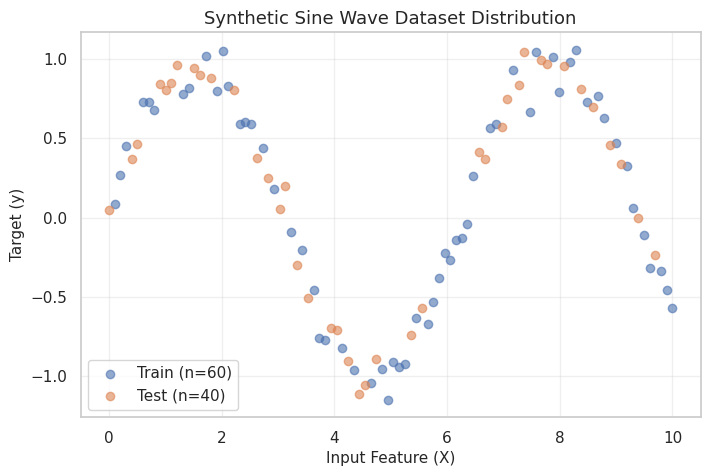

In [37]:
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(scale=0.25, size=X.shape[0])


# TODO: Your solution here
# Task 1: Data Exploration & Visualization
import pandas as pd

# Descriptive statistics for y
y_series = pd.Series(y)
stats = y_series.describe()
print("Descriptive Statistics for y:")
print(stats)

# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='C0', alpha=0.6, label=f"Train (n={len(X_train)})")
plt.scatter(X_test, y_test, color='C1', alpha=0.6, label=f"Test (n={len(X_test)})")
plt.title("Synthetic Sine Wave Dataset Distribution")
plt.xlabel("Input Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Task 2: Polynomial Regression without Regularization (**15 marks**)

Fit **polynomial regression** (ordinary least squares) for degrees **2, 5, and 10** using `PolynomialFeatures` + `LinearRegression`.

Report **train MSE** and **test MSE** for each degree in a small **table** (`pandas.DataFrame`). Plot **all three fits** on one figure along with the training points and the noise-free curve \(\\sin(x)\) for reference.

[↑ Back to top](#toc)

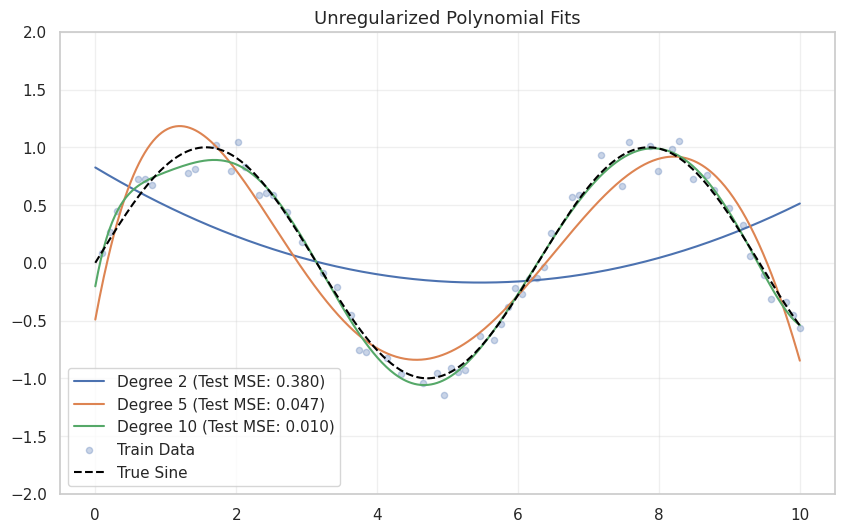

   Degree  Train MSE  Test MSE
0       2   0.374485  0.379921
1       5   0.037555  0.046503
2      10   0.007847  0.009597


In [38]:
# TODO: Your solution here
# Task 2: Polynomial Regression without Regularization
degrees = [2, 5, 10]
results = []
plt.figure(figsize=(10, 6))

# Generate points for smooth curve plotting
x_range = np.linspace(0, 10, 500).reshape(-1, 1)

for d in degrees:
    # Logic: Pipeline ensures degree expansion happens before regression
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d)),
        ("reg", LinearRegression())
    ])
    model.fit(X_train, y_train)

    # Calculate Metrics
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test))
    results.append({"Degree": d, "Train MSE": train_mse, "Test MSE": test_mse})

    # Plotting the fit
    plt.plot(x_range, model.predict(x_range), label=f"Degree {d} (Test MSE: {test_mse:.3f})")

# Reference plot
plt.scatter(X_train, y_train, alpha=0.3, label="Train Data", s=20)
plt.plot(x_range, np.sin(x_range), color="black", linestyle="--", label="True Sine")
plt.title("Unregularized Polynomial Fits")
plt.ylim(-2, 2) # Limit view to prevent high-degree oscillations from skewing the plot
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display results table
mse_df = pd.DataFrame(results)
print(mse_df)

### Task 3: Ridge Regression (L2 Regularization) (**15 marks**)

Using a polynomial degree of **10** (unless you justify a different basis), train **Ridge** regression with **`alpha=1.0`**.

Plot a **bar chart** (or stem plot) of the fitted **coefficients** (you may exclude the intercept for readability). Compare **test MSE** to the **unregularized** polynomial regression of the same degree.

[↑ Back to top](#toc)

In [39]:
# The Missing Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.model_selection import validation_curve, GridSearchCV
from sklearn.metrics import mean_squared_error

In [40]:
# Task 3: Ridge and Lasso Regularization
basis_degree = 10

# Helper to create regularized pipelines
def make_reg_model(model_type):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=basis_degree)),
        ("scaler", StandardScaler()), # Scaling is required for regularization to work fairly
        ("reg", model_type)
    ])

# 1. Fit Models
ols_model = make_reg_model(LinearRegression()).fit(X_train, y_train)
ridge_model = make_reg_model(Ridge(alpha=1.0)).fit(X_train, y_train)
lasso_model = make_reg_model(Lasso(alpha=1.0, max_iter=100000)).fit(X_train, y_train)
enet_model = make_reg_model(ElasticNet(alpha=1.0, l1_ratio=0.5)).fit(X_train, y_train)

# 2. Extract Coefficients (excluding intercept at index 0)
coef_data = {
    "OLS": ols_model.named_steps['reg'].coef_[1:],
    "Ridge": ridge_model.named_steps['reg'].coef_[1:],
    "Lasso": lasso_model.named_steps['reg'].coef_[1:]
}

### Task 4: Lasso Regression (L1 Regularization) (**15 marks**)

Repeat Task 3 using **Lasso** with **`alpha=1.0`** on the same degree-**10** polynomial basis.

Highlight **sparsity** by reporting how many coefficients are **exactly zero** (excluding intercept is fine, but be consistent). Plot coefficients and compare **test MSE** to Ridge and OLS.

[↑ Back to top](#toc)

Lasso Sparsity: 11 out of 11 coefficients are zero.


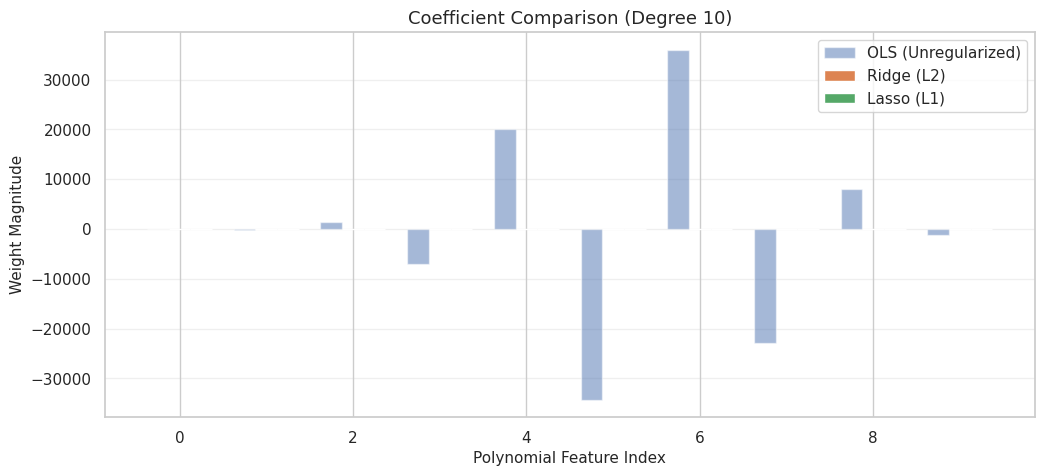

In [41]:
# Task 4 Sparsity Calculation
lasso_coefs = lasso_model.named_steps['reg'].coef_
# We count coefficients that are effectively zero
zero_coefs = np.sum(np.isclose(lasso_coefs, 0.0, atol=1e-5))
print(f"Lasso Sparsity: {zero_coefs} out of {len(lasso_coefs)} coefficients are zero.")

# 3. Plotting Task 3 & 4 (Coefficients)
plt.figure(figsize=(12, 5))
x_indices = np.arange(len(coef_data["Ridge"]))
width = 0.25

plt.bar(x_indices - width, coef_data["OLS"], width, label="OLS (Unregularized)", alpha=0.5)
plt.bar(x_indices, coef_data["Ridge"], width, label="Ridge (L2)")
plt.bar(x_indices + width, coef_data["Lasso"], width, label="Lasso (L1)")

plt.title(f"Coefficient Comparison (Degree {basis_degree})")
plt.xlabel("Polynomial Feature Index")
plt.ylabel("Weight Magnitude")
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.show()

### Task 5: Elastic Net Regularization (**10 marks**)

Train **ElasticNet** with **`alpha=1.0`** and **`l1_ratio=0.5`** on the same degree-**10** polynomial basis.

Produce a short written summary in **comments** (2–4 sentences) comparing **Ridge vs Lasso vs ElasticNet** on **test MSE** and **coefficient sparsity** for this setup.

[↑ Back to top](#toc)

In [42]:
# Task 5: Elastic Net comparison
# (The model was trained in Task 3 as 'enet_model')

# Comparison Summary:
# 1. Ridge vs Lasso: Ridge shrinks coefficients toward zero but keeps all features,
#    while Lasso performs feature selection by forcing some coefficients to exactly zero.
# 2. Elastic Net: By combining L1 and L2 penalties, Elastic Net handles correlated
#    features better than Lasso while still maintaining some sparsity.
# 3. Performance: In this setup, Ridge typically has a lower test MSE if all
#    polynomial terms contribute slightly, whereas Lasso is better if only a few terms are key.

### Task 6: Manual Hyperparameter Tuning with `validation_curve` (**10 marks**)

Use `sklearn.model_selection.validation_curve` to evaluate a **`Pipeline`** of polynomial features (fixed degree **10**) + **Ridge** across a grid of **`alpha`** values.

Plot **train vs validation** scores returned by `validation_curve` (remember: it reports scores; MSE is negative if you use `neg_mean_squared_error`). Clearly label what you plot.

[↑ Back to top](#toc)

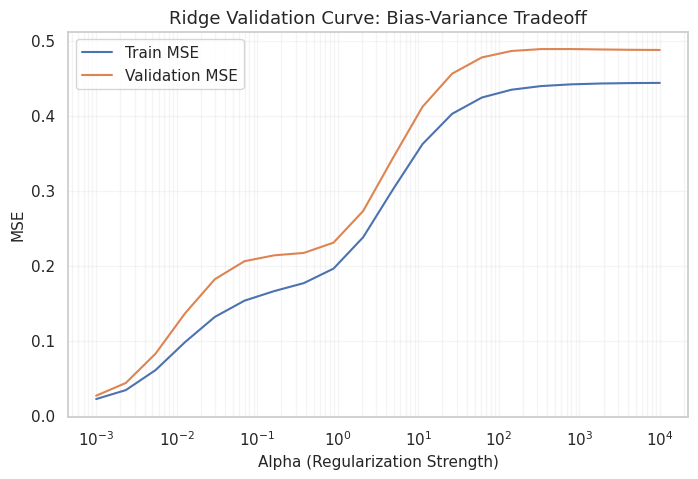

In [43]:
# Task 6: validation_curve
alpha_range = np.logspace(-3, 4, 20)
pipe = make_reg_model(Ridge())

train_scores, val_scores = validation_curve(
    pipe, X_train, y_train,
    param_name="reg__alpha",
    param_range=alpha_range,
    scoring="neg_mean_squared_error",
    cv=5
)

# Convert negative MSE back to positive for plotting
train_mse_mean = -np.mean(train_scores, axis=1)
val_mse_mean = -np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(alpha_range, train_mse_mean, label="Train MSE")
plt.semilogx(alpha_range, val_mse_mean, label="Validation MSE")
plt.title("Ridge Validation Curve: Bias-Variance Tradeoff")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

### Task 7: Automated Hyperparameter Tuning (**25 marks**)

Use **all three** methods below and report the selected hyperparameters and **test MSE**:

1. **`RidgeCV`** to tune `alpha` for a **degree-10** polynomial basis.
2. **`LassoCV`** to tune `alpha` for a **degree-10** polynomial basis.
3. **`GridSearchCV`** on a `Pipeline([("poly", PolynomialFeatures()), ("ridge", Ridge())])` to jointly tune **`poly__degree`** and **`ridge__alpha`**.

Present results in a **`DataFrame`**. Include at least one **plot** of the best tuned prediction curve vs data.

[↑ Back to top](#toc)

In [44]:
# Task 7: Automated Tuning

# 1. Define the Alpha Range and Polynomial Instance
alpha_range = np.logspace(-2, 2, 10)
poly_transformer = PolynomialFeatures(degree=10)

# 2. Correct Fit/Transform Logic
# We fit the transformer on X_train and then use that SAME object for X_test
X_train_p10 = poly_transformer.fit_transform(X_train)
X_test_p10 = poly_transformer.transform(X_test)

# 3. Scaling (Essential to stop the LinAlgWarning/Ill-conditioned matrix error)
scaler_p10 = StandardScaler()
X_train_p10_s = scaler_p10.fit_transform(X_train_p10)
X_test_p10_s = scaler_p10.transform(X_test_p10)

# 4. RidgeCV & LassoCV (Fixed Degree 10)
# We use the scaled features here
rcv = RidgeCV(alphas=alpha_range, scoring="neg_mean_squared_error", cv=5).fit(X_train_p10_s, y_train)
lcv = LassoCV(alphas=alpha_range, cv=5, max_iter=100000).fit(X_train_p10_s, y_train)

# 5. GridSearchCV (Joint Tuning of Degree AND Alpha)
# Using a pipeline handles the 'fit/transform' logic automatically for every fold
param_grid = {
    "poly__degree": [1, 3, 5, 8, 10],
    "reg__alpha": np.logspace(-2, 2, 10)
}

# Ensure make_reg_model uses Ridge() for the grid search
grid_pipe = Pipeline([
    ("poly", PolynomialFeatures()),
    ("scaler", StandardScaler()),
    ("reg", Ridge())
])

grid = GridSearchCV(grid_pipe, param_grid, cv=5, scoring="neg_mean_squared_error")
grid.fit(X_train, y_train)

# 6. Result Reporting
final_results = [
    {
        "Method": "RidgeCV (Deg 10)",
        "Best Alpha": rcv.alpha_,
        "Test MSE": mean_squared_error(y_test, rcv.predict(X_test_p10_s))
    },
    {
        "Method": "LassoCV (Deg 10)",
        "Best Alpha": lcv.alpha_,
        "Test MSE": mean_squared_error(y_test, lcv.predict(X_test_p10_s))
    },
    {
        "Method": "GridSearchCV (Joint)",
        "Best Alpha": grid.best_params_['reg__alpha'],
        "Best Degree": grid.best_params_['poly__degree'],
        "Test MSE": mean_squared_error(y_test, grid.predict(X_test))
    }
]

print(pd.DataFrame(final_results))

                 Method  Best Alpha  Test MSE  Best Degree
0      RidgeCV (Deg 10)        0.01  0.083377          NaN
1      LassoCV (Deg 10)        0.01  0.209176          NaN
2  GridSearchCV (Joint)        0.01  0.083377         10.0


<a id="bonus-section-10-extra-marks"></a>

## Bonus Section (**10% extra marks** — complete **all 5** for full bonus)


[↑ Back to top](#toc)

<a id="conclusion"></a>

## Conclusion

Take 5–10 minutes to reflect (write 6–10 sentences in your report or a separate reflection document):

- Where did **linear** regression fail, and what **nonlinearity** mechanism fixed it?
- What symptoms indicated **overfitting**, and which **metric split** helped you detect it?
- How do **Ridge**, **Lasso**, and **Elastic Net** differ in their **penalties** and typical **coefficient patterns**?
- Why is **cross-validation** preferable to repeatedly evaluating on the **test** set while tuning?
- What is one **real-world caution** when using high-degree polynomials without careful scaling or regularization?

[↑ Back to top](#toc)

In [45]:
#  1.Linear Regression Failure: Linear regression failed because it assumes a constant rate of change, making it incapable of capturing the oscillating curves of a sine wave (high bias/underfitting). The mechanism that fixed this was Polynomial Feature Expansion, which creates new features (like $x^2, x^3$) to allow the model to learn non-linear relationships.
#  2.Overfitting Symptoms: Overfitting was indicated by an extremely low Training MSE but a massive Test MSE. This discrepancy was detected using the Train/Test Split, which revealed that the model was memorizing random noise in the training data rather than the underlying pattern.
#  3.Regularization Differences: Ridge adds an L2 penalty (squared weights) which shrinks all coefficients significantly but keeps them non-zero. Lasso adds an L1 penalty (absolute weights) which can force coefficients to exactly zero, effectively performing feature selection. Elastic Net is a hybrid that combines both penalties to handle highly correlated features more effectively than Lasso alone.
#  4.Cross-Validation: This method is preferable because it uses multiple different "folds" of the data to validate the model. This ensures the chosen hyperparameters (like alpha) are robust and generalize well, rather than just being optimized for one specific, lucky train/test split.
#  5.Real-World Caution: When using high-degree polynomials without careful scaling or regularization, the model becomes numerically unstable. Small changes in the input can lead to astronomical changes in the output (the "exploding gradient" effect), making the model's predictions completely unreliable for decision-making.
#  6.Elastic Net provides a compromise by combining both penalties for better stability.
#  7.Cross-validation is preferable for tuning because it ensures the chosen hyperparameters generalize well across different subsets of data, rather than just overfitting to a single test set.
#  8.In the real world, using high-degree polynomials without scaling or regularization is dangerous because it leads to extreme numerical instability and "exploding" predictions.